In [22]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import plotly.express as px
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# Loading Dataset

In [2]:
df = pd.read_csv("../dataset/mobile_prices/train.csv")

In [3]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [4]:
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [5]:
X = df.drop(columns='price_range', axis=1)
y = df['price_range']

## Visualizing Classes

In [7]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(X)
pca_df = pd.DataFrame(
    x_pca,
    columns = ['C1', 'C2']
)

fig = px.scatter(
    pca_df,
    x = 'C1',
    y = 'C2',
    color = y,
    title = 'Class distribution in 2D PCA space'
)
fig.show()
fig.write_image("../visualizations/class_distribution_2d_pca.png")


# Train Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state = 42,
    stratify = y
)

In [9]:
kf = KFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
)

## Feature Scaling

In [10]:
scaler = StandardScaler()

In [11]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
y_train = np.array(y_train)

# Implementation

In [ ]:
class KNN:

    def __init__(self, k:int = 15, distance_func:str = 'manhattan'):
        self.k = k
        self.distance_func = distance_func
    
    # Just storing the data in fit method
    def fit(self, X, y):
        self.X = X
        self.y = y

    # ------------------------------------
    # Method to find Euclidean distance
    def euclidean(self, X1, X2):
        return np.sqrt(np.sum((X1-X2)**2))

    # ------------------------------------
    # Method to find Manhattan distance
    def manhattan(self, X1, X2):
        return np.sum(np.abs(X1-X2))


    # ------------------------------------
    # Method to predict
    def predict(self, X):
        distance = getattr(self, self.distance_func)   # to dynamically choose distance method

        predictions = []
        for sample in X:
            distances = []

            # finding distances for one sample
            for train_sample in self.X:
                
                d = distance(sample, train_sample)
                distances.append(d)
            
            distances = np.array(distances)
            k_indices = np.argsort(distances)[:self.k]
            k_labels = self.y[k_indices]
            prediction = np.bincount(k_labels).argmax()

            predictions.append(prediction)

        return np.array(predictions)

# Utility Functions

In [125]:
def see_optimum_k(accuracies, model_name:str):
    accuracies_df = pd.DataFrame(
    accuracies.items(),
    columns = ['K_value', 'Accuracy']
    )

    fig = px.line(
        accuracies_df,
        x = 'K_value',
        y = 'Accuracy',
        title = 'K values and corresponding accuracies'
    )
    fig.show()
    fig.write_image(f"../visualizations/optimum_k_{model_name}.png")

In [122]:
def get_model_accuracy(model):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return preds

# Checking Different Values of K : m-fold Cross Valideation

In [ ]:
accuracies = {}

for k in range(5,30):

    print(f"Checking for K:{k}")

    model = KNN()
    
    fold_accuracies = []
    
    for train_idx, val_idx in kf.split(X_train):
        X_fold_train = X_train[train_idx]
        X_fold_val = X_train[val_idx]

        y_fold_train = y_train[train_idx]
        y_fold_val = y_train[val_idx]

        model.fit(X_fold_train, y_fold_train, k=k, distance_func='euclidean')

        preds = model.predict(X_fold_val)
        acc = accuracy_score(y_fold_val, preds)
        fold_accuracies.append(acc)
    
    accuracies[k] = np.mean(fold_accuracies)


Checking for K:5
Checking for K:6
Checking for K:7
Checking for K:8
Checking for K:9
Checking for K:10
Checking for K:11
Checking for K:12
Checking for K:13
Checking for K:14
Checking for K:15
Checking for K:16
Checking for K:17
Checking for K:18
Checking for K:19
Checking for K:20
Checking for K:21
Checking for K:22
Checking for K:23
Checking for K:24
Checking for K:25
Checking for K:26
Checking for K:27
Checking for K:28
Checking for K:29


In [126]:
see_optimum_k(accuracies, "scratch_implemented")

Let's choose k = 15, as after that increase is accuracy is very slow

# Model Performance

### i) Using Euclidean Distance

In [112]:
model = KNN(k=15, distance_func='euclidean')
preds = get_model_accuracy(model)
print(f"Accuracy on k:15 and distance method: euclidean = ", round(accuracy_score(y_test, preds), 2)*100, "%")

Accuracy on k:15 and distance method: euclidean =  59.0 %


### ii) Using Manhattan Distance

In [113]:
model = KNN(k=15, distance_func='manhattan')
preds = get_model_accuracy(model)
print(f"Accuracy on k:15 and distance method: manhattan = ", round(accuracy_score(y_test, preds), 2)*100, "%")

Accuracy on k:15 and distance method: manhattan =  63.0 %


# Model in PCA Space

In [115]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

model = KNN()

model.fit(X_train_pca, y_train)
preds = model.predict(X_test_pca)

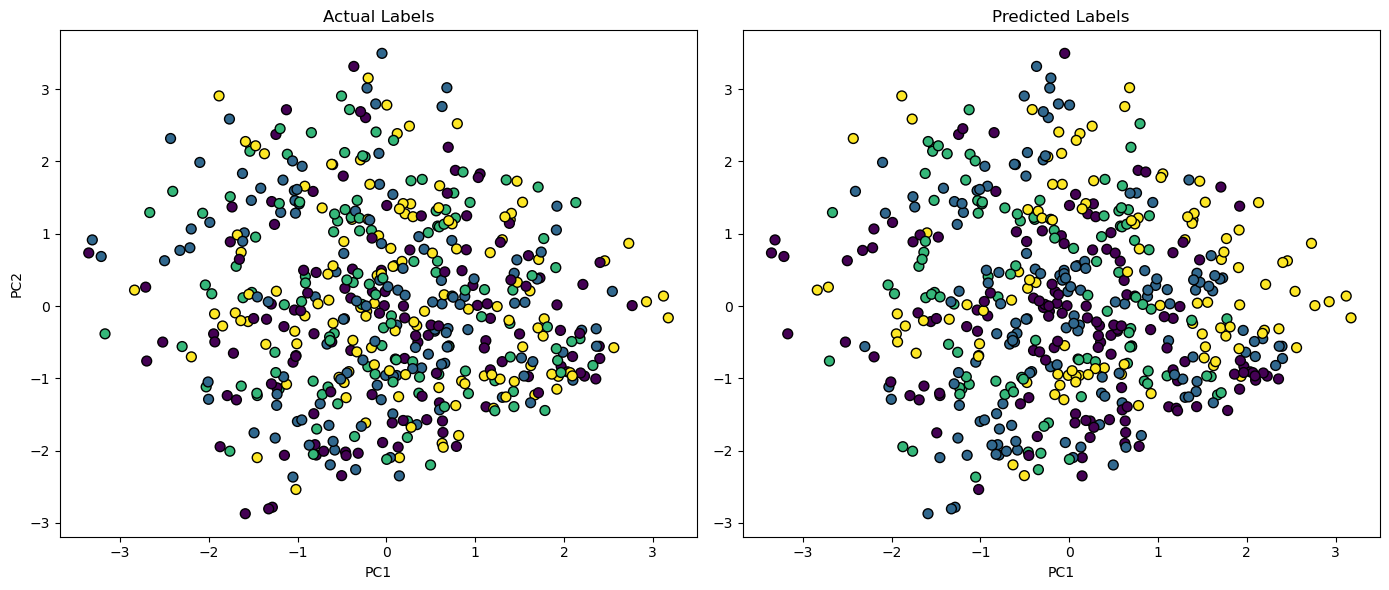

In [116]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Actual labels
ax[0].scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_test,
    cmap="viridis",
    edgecolor="k",
    s=50
)
ax[0].set_title("Actual Labels")
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")

# Predicted labels
ax[1].scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=preds,
    cmap="viridis",
    edgecolor="k",
    s=50
)
ax[1].set_title("Predicted Labels")
ax[1].set_xlabel("PC1")

plt.tight_layout()
plt.show()
fig.savefig("../visualizations/predictions_2d_pca.png")

# Sklearn Implementation

### Getting value of k

In [104]:
accuracies = {}

for k in range(1,30):

    print(f"Checking Accuracy for K:{k}")
    sklearn_model = KNeighborsClassifier(
        n_neighbors=k,
        metric="minkowski",
        p=2          # Euclidean Distance
        )

    fold_accuracies = []
    for train_idx, val_idx in kf.split(X_train):
        X_fold_train = X_train[train_idx]
        X_fold_val = X_train[val_idx]

        y_fold_train = y_train[train_idx]
        y_fold_val = y_train[val_idx]

        sklearn_model.fit(X_fold_train, y_fold_train)
        preds = sklearn_model.predict(X_fold_val)

        acc = accuracy_score(y_fold_val, preds)
        fold_accuracies.append(acc)

    accuracies[k] = np.array(fold_accuracies).mean()
    

Checking Accuracy for K:1
Checking Accuracy for K:2
Checking Accuracy for K:3
Checking Accuracy for K:4
Checking Accuracy for K:5
Checking Accuracy for K:6
Checking Accuracy for K:7
Checking Accuracy for K:8
Checking Accuracy for K:9
Checking Accuracy for K:10
Checking Accuracy for K:11
Checking Accuracy for K:12
Checking Accuracy for K:13
Checking Accuracy for K:14
Checking Accuracy for K:15
Checking Accuracy for K:16
Checking Accuracy for K:17
Checking Accuracy for K:18
Checking Accuracy for K:19
Checking Accuracy for K:20
Checking Accuracy for K:21
Checking Accuracy for K:22
Checking Accuracy for K:23
Checking Accuracy for K:24
Checking Accuracy for K:25
Checking Accuracy for K:26
Checking Accuracy for K:27
Checking Accuracy for K:28
Checking Accuracy for K:29


In [127]:
see_optimum_k(accuracies, "sklearn_model")

k = 15 is also optimum here

### Performance

#### i) Euclidean

In [120]:
sklearn_model = KNeighborsClassifier(
    n_neighbors = 15,
    metric = 'minkowski',
    p = 2
)

preds = get_model_accuracy(sklearn_model)
print(f"Accuracy on k:15 and distance method: euclidean = ", round(accuracy_score(y_test, preds), 2)*100, "%")

Accuracy on k:15 and distance method: euclidean =  59.0 %


#### ii) Manhattan

In [121]:
sklearn_model = KNeighborsClassifier(
    n_neighbors = 15,
    metric = 'minkowski',
    p = 1
)

preds = get_model_accuracy(sklearn_model)
print(f"Accuracy on k:15 and distance method: euclidean = ", round(accuracy_score(y_test, preds), 2)*100, "%")

Accuracy on k:15 and distance method: euclidean =  63.0 %
